In [ ]:
from pathlib import Path
from datetime import date
import inspect
import re

from Bio import SeqIO
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from pycirclize import Circos
from pycirclize.parser import Gff
from pycirclize.track import Track
from pycirclize.utils import calc_group_spaces, ColorCycler

In [ ]:
# Shared helper functions

def compute_gc_content(data, window_size=500, step_size=100):
    """Compute GC% in sliding windows.

    - If `data` is a FASTA filepath, process all records and return concatenated windows.
    - Otherwise, treat `data` as a nucleotide sequence string.
    """
    if isinstance(data, (str, Path)) and Path(str(data)).exists():
        positions, gc_values = [], []
        for record in SeqIO.parse(str(data), "fasta"):
            seq = str(record.seq).upper()
            for i in range(0, len(seq) - window_size + 1, step_size):
                window = seq[i:i + window_size]
                gc = (window.count("G") + window.count("C")) / window_size * 100
                positions.append(i + window_size // 2)
                gc_values.append(gc)
        return positions, gc_values

    seq = str(data).upper()
    n = len(seq)
    if n == 0:
        return [], []
    if n < window_size:
        gc = (seq.count("G") + seq.count("C")) / max(1, n) * 100
        return [n // 2], [gc]

    positions, gc_values = [], []
    for i in range(0, n - window_size + 1, step_size):
        w = seq[i:i + window_size]
        gc = (w.count("G") + w.count("C")) / window_size * 100
        positions.append(i + window_size // 2)
        gc_values.append(gc)
    return positions, gc_values


def get_seq_sizes(fasta):
    sizes = {}
    with open(fasta + ".fai") as f:
        for line in f:
            name, length = line.split()[:2]
            sizes[name] = int(length)
    return sizes


def compute_gc_content_skew(seq, window=500, step=100):
    """Return (positions, gc_content, gc_skew)."""
    positions, gc_content, gc_skew = [], [], []
    for i in range(0, len(seq) - window + 1, step):
        w = seq[i:i + window]
        g, c = w.count("G"), w.count("C")
        gc = (g + c) / window * 100
        skew = (g - c) / (g + c) if (g + c) > 0 else 0
        positions.append(i + window // 2)
        gc_content.append(gc)
        gc_skew.append(skew)
    return positions, np.array(gc_content), np.array(gc_skew)


def normalize_gene_id(gid):
    if gid is None:
        return ""
    gid = str(gid).strip()
    if not gid:
        return ""
    gid = gid.split(":")[0]
    gid = re.sub(r"-mRNA-\d+$", "", gid)
    gid = re.sub(r"-RNA-\d+$", "", gid)
    gid = re.sub(r"\.t\d+$", "", gid)
    return gid


def format_tick(v):
    av = abs(float(v))
    if av >= 10:
        return f"{v:.0f}"
    if av >= 1:
        return f"{v:.1f}"
    return f"{v:.2f}"


def compute_density(features, chrom_length, window_size=1_000_000, step_size=500_000):
    positions = []
    for feat in features:
        positions.append((int(feat.location.start) + int(feat.location.end)) / 2)
    positions = np.array(positions)
    if len(positions) == 0:
        return np.array([]), np.array([])

    midpoints, densities = [], []
    for win_start in range(0, chrom_length, step_size):
        win_end = min(win_start + window_size, chrom_length)
        if win_end <= win_start:
            continue
        count = np.sum((positions >= win_start) & (positions < win_end))
        midpoints.append((win_start + win_end) / 2)
        densities.append(count)
    return np.array(midpoints), np.array(densities)


def merge_intervals(intervals):
    """Merge overlapping or touching intervals given as (start, end) with half-open semantics."""
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [[intervals[0][0], intervals[0][1]]]
    for s, e in intervals[1:]:
        if s <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(s, e) for s, e in merged]


def compute_interval_coverage_percent(features, chrom_length, window_size=1_000_000, step_size=500_000):
    """Compute TE coverage (%) per sliding window using merged feature intervals."""
    intervals = []
    for feat in features:
        s = max(0, int(feat.location.start))
        e = min(int(chrom_length), int(feat.location.end))
        if e > s:
            intervals.append((s, e))

    if not intervals:
        return np.array([]), np.array([])

    merged = merge_intervals(intervals)
    midpoints, percentages = [], []

    i = 0
    for win_start in range(0, chrom_length, step_size):
        win_end = min(win_start + window_size, chrom_length)
        win_len = win_end - win_start
        if win_len <= 0:
            continue

        while i < len(merged) and merged[i][1] <= win_start:
            i += 1

        covered_bp = 0
        j = i
        while j < len(merged) and merged[j][0] < win_end:
            ov_start = max(win_start, merged[j][0])
            ov_end = min(win_end, merged[j][1])
            if ov_end > ov_start:
                covered_bp += (ov_end - ov_start)
            j += 1

        midpoints.append((win_start + win_end) / 2)
        percentages.append((covered_bp / win_len) * 100.0)

    return np.array(midpoints), np.array(percentages)

In [ ]:
# Shared paths and global variables
PROJECT_ROOT = Path("/home/apettersson/projects/LPED-assembly-QC")
PLOT_DIR = PROJECT_ROOT / "plots" / f"pyCirclize-{date.today().isoformat()}"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

RAW_PYCIRCLIZE_DIR = PROJECT_ROOT / "raw-data" / "pyCirclize"
PROCESSED_ANNOT_DIR = RAW_PYCIRCLIZE_DIR / "processedAnnotations"
PROCESSED_ASSEMBLY_DIR = RAW_PYCIRCLIZE_DIR / "processedAssemblies"
RAW_ANNOT_DIR = RAW_PYCIRCLIZE_DIR / "rawAnnotations"
RESULTS_TELOMERALITY_DIR = PROJECT_ROOT / "results" / "telomerality"

EMAPPER_FILE = str(RAW_ANNOT_DIR / "drLotPedu_hap1_hlxevi_proteins_2026-06-02.emapper.annotations")
DIPLOID_FAI = str(PROCESSED_ASSEMBLY_DIR / "diploid-assembly.fa.fai")
DIPLOID_STRUCT_GFF = str(PROCESSED_ANNOT_DIR / "diploid_chromosomes.gff")
DIPLOID_EDTA_GFF = str(PROCESSED_ANNOT_DIR / "diploidEDTAGFF.gff3")
FASTGA_LINKS_BED = str(PROCESSED_ASSEMBLY_DIR / "FastGAhap1_vs_hap2_synteny_filtered.bed")

BED_CANDIDATES = [
    PROCESSED_ANNOT_DIR / "telomere_centromere_regions_for_circos_latest.bed",
    RESULTS_TELOMERALITY_DIR / "telomere_centromere_regions_for_circos_latest.bed",
]

LABEL_SIZE = 7.2
ANNOT_MIN_R = 102.0
ANNOT_MAX_R = 112.0

GC_WINDOW = 20_000
GC_STEP = 5_000
DENSITY_WINDOW = 1_000_000
DENSITY_STEP = 500_000
TE_DENSITY_WINDOW = 1_000_000
TE_DENSITY_STEP = 500_000

HAP1_COLORS = ["darkorange", "orangered", "peru", "goldenrod", "sandybrown", "chocolate"]
HAP2_COLORS = ["dodgerblue", "navy", "royalblue", "steelblue", "cornflowerblue", "lightskyblue"]

FEATURE_COLOR = {"telomere": "#7b3294", "centromere": "#000000"}
MARK_ALPHA = 0.95
TEL_CAP_BP = 2_000_000
TEL_CAP_FRAC = 0.02

LSC_5P = (1, 99900)
IRA = (99900, 108100)
SSC = (108100, 128100)
IRB = (128100, 136500)
LSC_3P = (136500, 151652)
STRUCT_REGIONS = [
    ("LSC", LSC_5P[0], LSC_5P[1], "lightblue"),
    ("IRa", IRA[0], IRA[1], "tomato"),
    ("SSC", SSC[0], SSC[1], "lightgreen"),
    ("IRb", IRB[0], IRB[1], "tomato"),
    ("LSC", LSC_3P[0], LSC_3P[1], "lightblue"),
]

# DrLotPedu.Aarhus.v1 genome

Using focused regions BED: /home/apettersson/projects/LPED-assembly-QC/raw-data/pyCirclize/processedAnnotations/telomere_centromere_regions_for_circos_latest.bed
Loaded region rows: 31
Saved: /home/apettersson/projects/LPED-assembly-QC/plots/pyCirclize-2026-06-16/diploid_circos.png
Saved: /home/apettersson/projects/LPED-assembly-QC/plots/pyCirclize-2026-06-16/diploid_circos.pdf


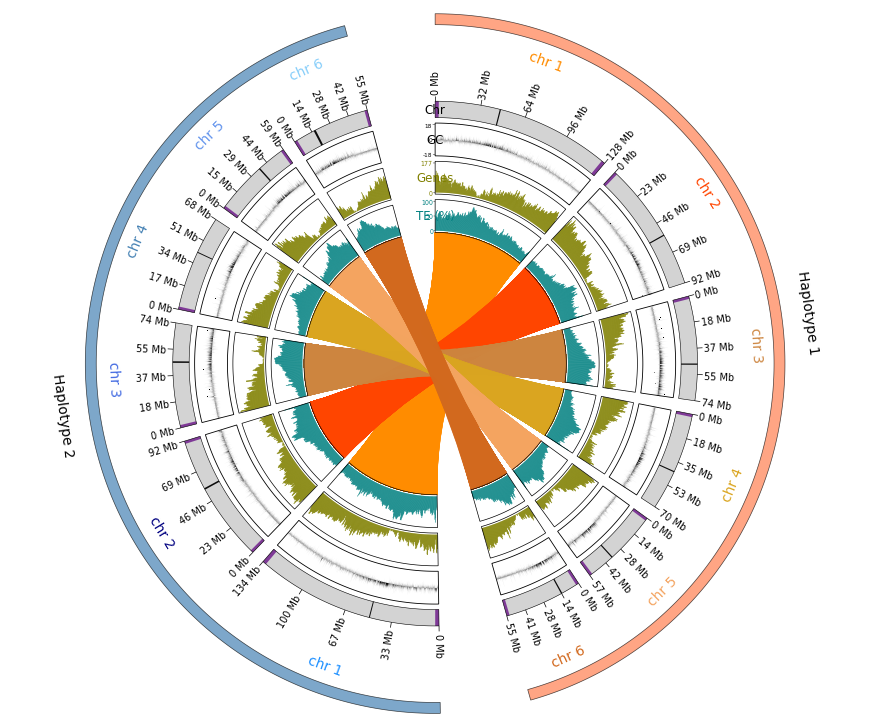

In [ ]:
# Trial with FastGA links
hap1_colors = HAP1_COLORS
hap2_colors = HAP2_COLORS

regions_bed = next((p for p in BED_CANDIDATES if p.exists()), None)
if regions_bed is None:
    raise FileNotFoundError("Could not find telomere/centromere BED in expected locations.")

regions_df = pd.read_csv(
    regions_bed,
    sep="\t",
    header=None,
    names=["chr", "start0", "end", "name", "score", "strand"],
)
name_parts = regions_df["name"].astype(str).str.split("_", n=2, expand=True)
regions_df["feature"] = name_parts[0].fillna("")
regions_df["side"] = name_parts[1].fillna("")
regions_df["confidence"] = name_parts[2].fillna("")
regions_by_chr = {k: v.copy().reset_index(drop=True) for k, v in regions_df.groupby("chr", sort=False)}

# ---- Load chromosome sizes from FAI ----
fai = pd.read_csv(
    DIPLOID_FAI,
    sep="\t",
    header=None,
    usecols=[0, 1],
    names=["chr", "length"],
)
sectors = {row.chr: (0, int(row.length)) for _, row in fai.iterrows()}

# Load genome sequences for GC-content calculation
genome_fasta = DIPLOID_FAI[:-4] if DIPLOID_FAI.endswith(".fai") else DIPLOID_FAI
seqid2seq = {rec.id: str(rec.seq).upper() for rec in SeqIO.parse(genome_fasta, "fasta")}

# Global mean GC across all plotted chromosomes
total_len = sum(len(seqid2seq.get(s, "")) for s in sectors.keys())
total_gc = sum(
    seqid2seq.get(s, "").count("G") + seqid2seq.get(s, "").count("C")
    for s in sectors.keys()
)
genome_gc_mean = (total_gc / total_len * 100) if total_len > 0 else 0.0

struct_gff = Gff(DIPLOID_STRUCT_GFF)
seqid2struct_features = struct_gff.get_seqid2features(feature_type="gene")
if not any(len(v) > 0 for v in seqid2struct_features.values()):
    seqid2struct_features = struct_gff.get_seqid2features(feature_type="mRNA")
if not any(len(v) > 0 for v in seqid2struct_features.values()):
    seqid2struct_features = struct_gff.get_seqid2features(feature_type="CDS")

edta_gff = Gff(DIPLOID_EDTA_GFF)
seqid2edta_features = edta_gff.get_seqid2features(feature_type=None)
if not any(len(v) > 0 for v in seqid2edta_features.values()):
    seqid2edta_features = edta_gff.get_seqid2features(feature_type="repeat_region")

# ---- Define haplotype groups ----
hap1_names = sorted([s for s in sectors.keys() if s.startswith("hap1_")])
hap2_names = sorted([s for s in sectors.keys() if s.startswith("hap2_")])
other_names = sorted([s for s in sectors.keys() if s not in hap1_names and s not in hap2_names])

group_lists = []
if hap1_names:
    group_lists.append(hap1_names)
if hap2_names:
    group_lists.append(hap2_names)
if other_names:
    group_lists.append(other_names)

group_sizes = [len(g) for g in group_lists]
spaces = calc_group_spaces(group_sizes, space_bw_group=15, space_in_group=3)

# ---- Initialize Circos ----
circos = Circos(sectors, space=spaces)

# Keep chromosome palette dictionary for link colors only
hap1_color_dict = {name: hap1_colors[i % len(hap1_colors)] for i, name in enumerate(hap1_names)}
hap2_color_dict = {name: hap2_colors[i % len(hap2_colors)] for i, name in enumerate(hap2_names)}
ColorCycler.set_cmap("tab20")
other_palette = ColorCycler.get_color_list(max(1, len(other_names)))
other_color_dict = {name: other_palette[i] for i, name in enumerate(other_names)}
chr_name2color = {**hap1_color_dict, **hap2_color_dict, **other_color_dict}

# ---- Haplotype group outer arcs ----
group_colors, group_labels = [], []
if hap1_names:
    group_colors.append("coral")
    group_labels.append("Haplotype 1")
if hap2_names:
    group_colors.append("steelblue")
    group_labels.append("Haplotype 2")
if other_names:
    group_colors.append("lightgrey")
    group_labels.append("Unplaced")

for group, color, label in zip(group_lists, group_colors, group_labels):
    group_deg_lim = circos.get_group_sectors_deg_lim(group)
    circos.rect(r_lim=(124, 128), deg_lim=group_deg_lim, fc=color, ec="black", lw=0.5, alpha=0.7)
    group_center_deg = sum(group_deg_lim) / 2
    circos.text(label, r=135, deg=group_center_deg, adjust_rotation=True, size=10)

# ---- Precompute track data + global scales ----
struct_density_by_sector, te_coverage_by_sector, gc_dev_by_sector = {}, {}, {}
struct_global_max, gc_global_abs_max = 1.0, 1.0
te_global_max = 100.0

for sname, srange in sectors.items():
    chrom_len = int(srange[1])
    d_x, d_y = compute_density(seqid2struct_features.get(sname, []), chrom_len, DENSITY_WINDOW, DENSITY_STEP)
    struct_density_by_sector[sname] = (d_x, d_y)
    if len(d_y) > 0:
        struct_global_max = max(struct_global_max, float(np.max(d_y)))

    te_x, te_pct = compute_interval_coverage_percent(
        seqid2edta_features.get(sname, []),
        chrom_len,
        TE_DENSITY_WINDOW,
        TE_DENSITY_STEP,
    )
    te_coverage_by_sector[sname] = (te_x, te_pct)

    x, gc_raw = compute_gc_content(seqid2seq.get(sname, ""), GC_WINDOW, GC_STEP)
    if x:
        gc_raw = np.array(gc_raw, dtype=float)
        gc_dev = gc_raw - genome_gc_mean
        gc_dev_by_sector[sname] = (np.array(x, dtype=float), gc_dev)
        gc_global_abs_max = max(gc_global_abs_max, float(np.max(np.abs(gc_dev))))
    else:
        gc_dev_by_sector[sname] = (np.array([]), np.array([]))

if gc_global_abs_max == 0:
    gc_global_abs_max = 1.0

TRACK_LABEL_DEG_CHR = 0
TRACK_LABEL_DEG_GC = 0
TRACK_LABEL_DEG_GENES = 0
TRACK_LABEL_DEG_TE = 0

# ---- Plot tracks ----
for sector in circos.sectors:
    # 1) Chromosome track (gray base)
    outer_track = sector.add_track((90, 96))
    outer_track.axis(fc="lightgrey", ec="black", lw=0.4)
    outer_track.xticks_by_interval(
        max(1, sector.size // 4),
        label_size=7,
        label_orientation="vertical",
        label_formatter=lambda v: f"{v / 1_000_000:.0f} Mb",
    )

    # Telomere + centromere overlays with qualitative semantics
    sector_regions = regions_by_chr.get(sector.name)
    if sector_regions is not None and len(sector_regions) > 0:
        feature_series = sector_regions["feature"].astype(str).str.lower()
        tel_regions = sector_regions[feature_series == "telomere"]
        cen_regions = sector_regions[feature_series == "centromere"]

        # Telomere caps: fixed cap size, independent of telomere region length
        if len(tel_regions) > 0:
            tel_sides = set(tel_regions["side"].astype(str).str.lower())
            cap_bp = int(max(TEL_CAP_BP, int(sector.size * TEL_CAP_FRAC)))
            cap_bp = min(cap_bp, max(1, int(sector.size // 8)))
            cap_bp = max(1, cap_bp)

            if "left" in tel_sides:
                outer_track.rect(0, min(cap_bp, int(sector.size)), r_lim=(90, 96), fc=FEATURE_COLOR["telomere"], ec="none", alpha=MARK_ALPHA)
            if "right" in tel_sides:
                start = max(0, int(sector.size) - cap_bp)
                outer_track.rect(start, int(sector.size), r_lim=(90, 96), fc=FEATURE_COLOR["telomere"], ec="none", alpha=MARK_ALPHA)

        # Centromere stays quantitative by reported region, but fixed black color
        if len(cen_regions) > 0:
            for _, reg in cen_regions.iterrows():
                s = max(0, int(reg["start0"]))
                e = min(int(sector.size), int(reg["end"]))
                if e <= s:
                    continue
                outer_track.rect(s, e, r_lim=(90, 96), fc=FEATURE_COLOR["centromere"], ec="none", alpha=MARK_ALPHA)

    # 2) Structural feature density
    density_track = sector.add_track((62, 74), r_pad_ratio=0.1)
    density_track.axis(fc="none", ec="black", lw=0.5)
    d_x, d_y = struct_density_by_sector.get(sector.name, (np.array([]), np.array([])))
    if len(d_x) > 0:
        density_track.bar(d_x, d_y, vmax=struct_global_max, width=DENSITY_WINDOW * 0.7, color="olive", ec="none")

    # 3) TE coverage percentage
    te_track = sector.add_track((48, 60), r_pad_ratio=0.1)
    te_track.axis(fc="none", ec="black", lw=0.5)
    te_x, te_y = te_coverage_by_sector.get(sector.name, (np.array([]), np.array([])))
    if len(te_x) > 0:
        te_track.bar(te_x, te_y, vmax=te_global_max, width=TE_DENSITY_WINDOW * 0.7, color="teal", ec="none")

    # 4) GC deviation
    gc_track = sector.add_track((76, 88), r_pad_ratio=0.1)
    gc_track.axis(fc="none", ec="black", lw=0.6)
    x, gc_dev = gc_dev_by_sector.get(sector.name, (np.array([]), np.array([])))
    if len(x) > 0:
        pos_gc = np.where(gc_dev > 0, gc_dev, 0)
        neg_gc = np.where(gc_dev < 0, gc_dev, 0)
        vmin, vmax = -gc_global_abs_max, gc_global_abs_max
        gc_track.fill_between(x, pos_gc, 0, vmin=vmin, vmax=vmax, color="black")
        gc_track.fill_between(x, neg_gc, 0, vmin=vmin, vmax=vmax, color="grey")

    # Tiny y-axis labels for first sector only (to avoid clutter)
    if sector.name == circos.sectors[0].name:
        density_track.yticks(
            [0, struct_global_max],
            labels=["0", f"{int(round(struct_global_max))}"],
            vmin=0,
            vmax=struct_global_max,
            side="left",
            tick_length=0.6,
            label_size=4.5,
            label_margin=0.2,
            line_kws=dict(ec="black", lw=0.3),
            text_kws=dict(color="olive"),
        )
        te_track.yticks(
            [0, 50, 100],
            labels=["0", "50", "100"],
            vmin=0,
            vmax=100,
            side="left",
            tick_length=0.6,
            label_size=4.5,
            label_margin=0.2,
            line_kws=dict(ec="black", lw=0.3),
            text_kws=dict(color="teal"),
        )
        gc_ticks = [-gc_global_abs_max, 0, gc_global_abs_max]
        gc_track.yticks(
            gc_ticks,
            labels=[format_tick(gc_ticks[0]), "0", format_tick(gc_ticks[2])],
            vmin=-gc_global_abs_max,
            vmax=gc_global_abs_max,
            side="left",
            tick_length=0.6,
            label_size=4.2,
            label_margin=0.2,
            line_kws=dict(ec="black", lw=0.3),
            text_kws=dict(color="black"),
        )

    short_name = sector.name.replace("hap1_", "").replace("hap2_", "").replace("chr", "chr ")
    sector.text(short_name, r=115, size=10, color=chr_name2color[sector.name])

    # Keep track labels
    if sector.name == circos.sectors[0].name:
        circos.text("Chr", r=outer_track.r_center, deg=TRACK_LABEL_DEG_CHR, size=8.5, color="black")
        circos.text("GC", r=gc_track.r_center, deg=TRACK_LABEL_DEG_GC, size=8.5, color="black")
        circos.text("Genes", r=density_track.r_center, deg=TRACK_LABEL_DEG_GENES, size=8.5, color="olive")
        circos.text("TE (%)", r=te_track.r_center, deg=TRACK_LABEL_DEG_TE, size=8.5, color="teal")

# ---- Plot collinearity links ----
links_raw = pd.read_csv(FASTGA_LINKS_BED, sep="\t", header=None)
if links_raw.shape[1] >= 9:
    links = links_raw.iloc[:, [0, 2, 3, 5, 7, 8]].copy()
elif links_raw.shape[1] >= 6:
    links = links_raw.iloc[:, [0, 1, 2, 3, 4, 5]].copy()
else:
    raise ValueError(f"Unsupported links format with {links_raw.shape[1]} columns")
links.columns = ["chr1", "s1", "e1", "chr2", "s2", "e2"]

for _, row in links.iterrows():
    if row.chr1 == row.chr2:
        continue
    if row.chr1 not in chr_name2color or row.chr2 not in chr_name2color:
        continue
    if str(row.chr1).startswith("hap1_"):
        hap1_chr = row.chr1
    elif str(row.chr2).startswith("hap1_"):
        hap1_chr = row.chr2
    else:
        hap1_chr = row.chr1
    color = chr_name2color.get(hap1_chr, "darkorange")
    p1 = (int(row.s1) + int(row.e1)) // 2
    p2 = (int(row.s2) + int(row.e2)) // 2
    if hasattr(circos, "link_line"):
        circos.link_line((row.chr1, p1), (row.chr2, p2), color=color, lw=0.35)
    else:
        circos.link((row.chr1, p1, p1 + 1), (row.chr2, p2, p2 + 1), color=color)

# ---- Save (no legend) ----
fig = circos.plotfig()
png_out = PLOT_DIR / "diploid_circos.png"
pdf_out = PLOT_DIR / "diploid_circos.pdf"
fig.savefig(str(png_out), dpi=300, bbox_inches="tight")
fig.savefig(str(pdf_out), dpi=300, bbox_inches="tight")

print(f"Using focused regions BED: {regions_bed}")
print(f"Loaded region rows: {len(regions_df)}")
print(f"Saved: {png_out}")
print(f"Saved: {pdf_out}")